# nb07 -- Two-layer sparse MLP + gene importance validation
Two extensions over nb06:

1. **Architecture**: L1 penalty on both `fc1` (gene->hidden) and `fc2` (hidden->protein), not just `fc1`. This forces each protein to depend on a small subset of the 64 hidden units, so the two-hop gene->hidden->protein path becomes genuinely per-protein-specific instead of every protein reading from all 64 units.
2. **Validation of gene importance**: before trusting any importance ranking biologically, check whether it's even stable and above chance.
   - **Bootstrap stability** -- retrain on resampled cells, check whether the same top genes keep showing up per protein.
   - **Permutation null** -- retrain on RNA paired with shuffled protein values (real relationship destroyed), see how large importance scores get from pure noise, and use that as a significance threshold for the real model.

All evaluation is reported on train AND test throughout -- the goal here is characterizing the relationship itself, not just held-out prediction accuracy.

Pathway/complex-membership validation (STRING/CORUM) is deliberately left for a later notebook, once we know which genes actually survive stability + null checks.

## Environment setup

In [1]:
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q scanpy anndata scikit-misc
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/covid_citeseq_project')
else:
    BASE_PATH = Path('..')

print(f"Running on {'Colab' if IN_COLAB else 'local'} | BASE_PATH = {BASE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running on Colab | BASE_PATH = /content/drive/MyDrive/covid_citeseq_project


## GPU check

In [2]:
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device (training only):', DEVICE)

Device (training only): cuda


## Imports and config

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scanpy as sc
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

CHECKPOINT_PATH    = BASE_PATH / 'data' / 'processed' / 'covid_subsampled.h5ad'
GENE_MAPPING_PATH  = BASE_PATH / 'results' / 'tables' / 'nb02_covid_adt_gene_mapping.csv'
RESULTS_DIR        = BASE_PATH / 'results' / 'sparse_mlp_v2'
MODELS_DIR         = RESULTS_DIR / 'checkpoints'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

N_HVGS       = 2000
DROP_GENES   = ['PDPN', 'KDR']  # zero-variance in GEX (see nb02 Step 3b)

HIDDEN_DIM     = 64
L1_LAMBDA_FC1  = 1e-4   # gene -> hidden
L1_LAMBDA_FC2  = 1e-4   # hidden -> protein
BATCH_SIZE     = 256
NUM_EPOCHS     = 100
PATIENCE       = 15

TEST_SIZE     = 0.15
VAL_SIZE      = 0.15
RANDOM_STATE  = 42

CELL_TYPE_COL = 'full_clustering'  # confirmed in nb06

# Validation run budgets -- each bootstrap/null run is a full training pass,
# so these are capped lower than the main model to keep total runtime bounded.
N_BOOTSTRAPS      = 5
N_NULL_PERMS      = 5
AUX_NUM_EPOCHS    = 40
AUX_PATIENCE      = 8
TOP_K_GENES       = 20    # per-protein top-K used for stability scoring

## Load checkpoint and gene mapping

In [4]:
covid = sc.read_h5ad(CHECKPOINT_PATH)

gex_mask = covid.var['feature_types'] == 'Gene Expression'
adt_mask = covid.var['feature_types'] == 'Antibody Capture'
covid_gex = covid[:, gex_mask].copy()
covid_adt = covid[:, adt_mask].copy()

gene_map = pd.read_csv(GENE_MAPPING_PATH)
gene_map = gene_map[~gene_map['gene'].isin(DROP_GENES)]
matched_genes     = gene_map['gene'].tolist()
matched_adt_names = gene_map['adt_name'].tolist()

cell_types = covid.obs[CELL_TYPE_COL].values

print(f'GEX: {covid_gex.shape}, ADT: {covid_adt.shape}')
print(f'Matched genes/proteins: {len(matched_genes)}')

GEX: (69090, 24737), ADT: (69090, 192)
Matched genes/proteins: 163


## Gene union (matched + HVG)

In [5]:
covid_gex.layers['counts'] = covid_gex.layers['raw'].copy()

sc.pp.highly_variable_genes(
    covid_gex, n_top_genes=N_HVGS, flavor='seurat_v3', layer='counts',
)
hvg_genes = covid_gex.var_names[covid_gex.var['highly_variable']].tolist()


def build_gene_union(matched_genes: list[str], hvg_genes: list[str]) -> list[str]:
    """Union of matched coupling genes and top HVGs, matched genes always included."""
    return sorted(set(matched_genes) | set(hvg_genes))


gene_union = build_gene_union(matched_genes, hvg_genes)
print(f'Gene union: {len(gene_union)}')

Gene union: 2092


## Normalize and correct (same pipeline as nb06)
Log1p(CP10k) RNA, CLR protein, library-size regression on both -- unchanged from nb06 so results are comparable across notebooks.

In [6]:
def normalize_rna(adata_gex: sc.AnnData, gene_union: list[str]) -> sc.AnnData:
    """Log1p(CP10k) normalization on raw counts, restricted to gene_union."""
    adata = adata_gex[:, gene_union].copy()
    adata.X = adata.layers['raw'].copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    return adata


def clr_normalize(counts: np.ndarray) -> np.ndarray:
    """Centered log-ratio normalization per cell -- standard for CITE-seq ADT counts."""
    log_counts = np.log1p(counts)
    geometric_mean = log_counts.mean(axis=1, keepdims=True)
    return log_counts - geometric_mean


def regress_out_library_size(X: np.ndarray, raw_counts_layer: np.ndarray) -> np.ndarray:
    """Residualize each column of X against log1p(per-cell total raw counts)."""
    lib_size = np.log1p(np.asarray(raw_counts_layer).sum(axis=1)).reshape(-1, 1)
    design = np.column_stack([np.ones(X.shape[0]), lib_size])
    beta, _, _, _ = np.linalg.lstsq(design, X, rcond=None)
    return (X - design @ beta).astype(np.float32)


rna_adata = normalize_rna(covid_gex, gene_union)
X_rna = np.asarray(rna_adata.X.todense()) if hasattr(rna_adata.X, 'todense') else np.asarray(rna_adata.X)
X_rna = X_rna.astype(np.float32)

adt_counts = covid_adt[:, matched_adt_names].layers['raw']
adt_counts = np.asarray(adt_counts.todense()) if hasattr(adt_counts, 'todense') else np.asarray(adt_counts)
Y_protein = clr_normalize(adt_counts).astype(np.float32)

rna_raw_for_size = rna_adata.layers['raw']
rna_raw_for_size = np.asarray(rna_raw_for_size.todense()) if hasattr(rna_raw_for_size, 'todense') else np.asarray(rna_raw_for_size)

X_rna_corr     = regress_out_library_size(X_rna, rna_raw_for_size)
Y_protein_corr = regress_out_library_size(Y_protein, adt_counts)

print(f'X_rna_corr: {X_rna_corr.shape} | Y_protein_corr: {Y_protein_corr.shape}')

X_rna_corr: (69090, 2092) | Y_protein_corr: (69090, 163)


## Train / val / test split

In [7]:
n_cells = X_rna_corr.shape[0]
all_idx = np.arange(n_cells)

train_idx, test_idx = train_test_split(all_idx, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, val_idx  = train_test_split(train_idx, test_size=VAL_SIZE / (1 - TEST_SIZE), random_state=RANDOM_STATE)

print(f'Train: {len(train_idx):,} | Val: {len(val_idx):,} | Test: {len(test_idx):,}')

Train: 48,362 | Val: 10,364 | Test: 10,364


## DataLoaders

In [8]:
def make_loader(X: np.ndarray, Y: np.ndarray, idx: np.ndarray, batch_size: int, shuffle: bool) -> DataLoader:
    ds = TensorDataset(torch.from_numpy(X[idx]), torch.from_numpy(Y[idx]))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=shuffle)


train_loader = make_loader(X_rna_corr, Y_protein_corr, train_idx, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(X_rna_corr, Y_protein_corr, val_idx,   BATCH_SIZE, shuffle=False)

## `SparseGeneToProteinMLP` architecture (unchanged structurally)
Same single hidden layer. The change is in training: L1 now applies to both `fc1` and `fc2`.

In [9]:
class SparseGeneToProteinMLP(nn.Module):
    """RNA -> hidden -> protein, multi-output regression.

    rna_dim     : number of input genes.
    hidden_dim  : hidden layer width.
    protein_dim : number of output proteins, predicted jointly.
    """

    def __init__(self, rna_dim: int, hidden_dim: int, protein_dim: int):
        super().__init__()
        self.fc1 = nn.Linear(rna_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, protein_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.fc2(self.relu(self.fc1(x)))

## Training loop -- L1 on fc1 + fc2, GPU for training, CPU for validation
Same device pattern as nb06: model moves to GPU only for the training pass; validation and the final returned model stay on CPU.

In [10]:
def fit_sparse_mlp(model: nn.Module,
                    train_loader: DataLoader,
                    val_loader: DataLoader,
                    l1_lambda_fc1: float,
                    l1_lambda_fc2: float,
                    num_epochs: int,
                    patience: int,
                    checkpoint_path: Path,
                    train_device: torch.device,
                    verbose: bool = True):
    """Train with MSE + L1(fc1.weight) + L1(fc2.weight) on train_device; validate on CPU each epoch."""
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.to(train_device)
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(train_device), yb.to(train_device)
            optimizer.zero_grad()
            pred = model(xb)
            l1_penalty = l1_lambda_fc1 * model.fc1.weight.abs().sum() + l1_lambda_fc2 * model.fc2.weight.abs().sum()
            loss = criterion(pred, yb) + l1_penalty
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
        train_loss = total_loss / len(train_loader.dataset)

        model.to('cpu')
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                val_loss += criterion(model(xb), yb).item() * xb.size(0)
        val_loss /= len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f'  Early stopping at epoch {epoch}')
                break

        if verbose and epoch % 10 == 0:
            print(f'  Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}')

    model.load_state_dict(best_state)
    model.to('cpu')
    if checkpoint_path is not None:
        torch.save(model.state_dict(), checkpoint_path)
    return model, history

## Train the global model (L1 on fc1 + fc2)

In [11]:
print('Training global model (two-layer sparsity)...')
global_model = SparseGeneToProteinMLP(
    rna_dim=X_rna_corr.shape[1], hidden_dim=HIDDEN_DIM, protein_dim=Y_protein_corr.shape[1],
)
global_model, global_history = fit_sparse_mlp(
    model=global_model,
    train_loader=train_loader,
    val_loader=val_loader,
    l1_lambda_fc1=L1_LAMBDA_FC1,
    l1_lambda_fc2=L1_LAMBDA_FC2,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    checkpoint_path=MODELS_DIR / 'global_model.pt',
    train_device=DEVICE,
)

Training global model (two-layer sparsity)...
  Epoch 0: train_loss=0.3698, val_loss=0.2788
  Epoch 10: train_loss=0.2888, val_loss=0.2665
  Epoch 20: train_loss=0.2874, val_loss=0.2653
  Epoch 30: train_loss=0.2871, val_loss=0.2653
  Epoch 40: train_loss=0.2870, val_loss=0.2652
  Epoch 50: train_loss=0.2870, val_loss=0.2650
  Early stopping at epoch 59


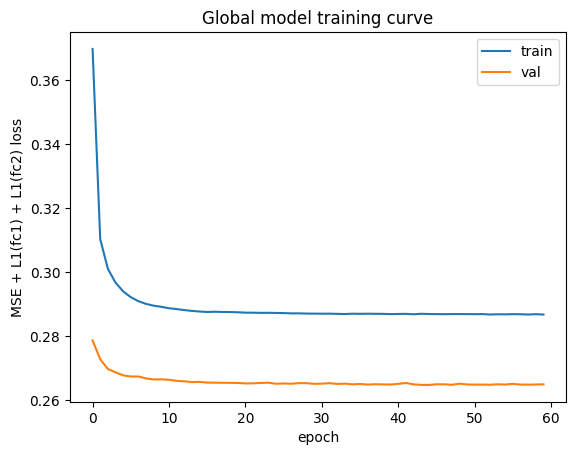

In [12]:
plt.plot(global_history['train_loss'], label='train')
plt.plot(global_history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('MSE + L1(fc1) + L1(fc2) loss')
plt.legend()
plt.title('Global model training curve')
plt.show()

## Sparsity check -- both layers
Reports fc1 (gene->hidden) and fc2 (hidden->protein) sparsity separately, then the practically important number: how many genes actually feed into each protein's prediction once both layers are pruned.

In [13]:
def layer_sparsity(W: np.ndarray, thresh: float = 1e-3) -> float:
    """Fraction of near-zero weights in a weight matrix."""
    return float((np.abs(W) < thresh).mean())


W1 = global_model.fc1.weight.detach().numpy()  # (hidden, genes)
W2 = global_model.fc2.weight.detach().numpy()  # (proteins, hidden)

print(f'fc1 sparsity (gene->hidden): {layer_sparsity(W1):.1%}')
print(f'fc2 sparsity (hidden->protein): {layer_sparsity(W2):.1%}')


def effective_genes_per_protein(W1: np.ndarray, W2: np.ndarray, protein_names: list[str],
                                 gene_names: list[str], thresh: float = 1e-3) -> pd.DataFrame:
    """For each protein: active hidden units (from fc2), then union of genes feeding
    those units (from fc1). This is the real explainability payoff of two-layer sparsity.
    """
    rows = []
    for pi, protein in enumerate(protein_names):
        active_units = np.where(np.abs(W2[pi, :]) >= thresh)[0]
        if len(active_units) == 0:
            rows.append({'protein': protein, 'n_active_hidden_units': 0, 'n_effective_genes': 0})
            continue
        active_gene_mask = (np.abs(W1[active_units, :]) >= thresh).any(axis=0)
        rows.append({
            'protein': protein,
            'n_active_hidden_units': len(active_units),
            'n_effective_genes': int(active_gene_mask.sum()),
        })
    return pd.DataFrame(rows)


effective_genes = effective_genes_per_protein(W1, W2, matched_adt_names, gene_union)
print(f"\nMedian effective genes per protein: {effective_genes['n_effective_genes'].median():.0f} (out of {len(gene_union)})")
effective_genes.sort_values('n_effective_genes').head(10)

fc1 sparsity (gene->hidden): 88.9%
fc2 sparsity (hidden->protein): 65.1%

Median effective genes per protein: 1351 (out of 2092)


,protein,n_active_hidden_units,n_effective_genes
78,AB_CX3CR1,16,1254
26,AB_MME,15,1272
51,AB_CXCR5,16,1278
13,AB_CD40,18,1287
137,AB_NCR2,9,1291
108,AB_ITGA2,17,1307
92,AB_VCAM1,15,1312
12,AB_TNFRSF8,14,1313
105,AB_CD226,24,1316
40,AB_PTGDR2,18,1318


## Evaluation function (CPU only, train and test both)
Same pattern as nb06 -- every metric reported on train and test side by side, since the goal is characterizing the relationship, not just held-out prediction.

In [14]:
def evaluate_per_protein(model: nn.Module, X: np.ndarray, Y: np.ndarray,
                          protein_names: list[str], return_preds: bool = False):
    """Per-protein Pearson r and R2 on CPU. Optionally also return raw predictions."""
    model.to('cpu')
    model.eval()
    with torch.no_grad():
        preds = model(torch.from_numpy(X)).numpy()
    rows = []
    for i, name in enumerate(protein_names):
        r, _ = pearsonr(Y[:, i], preds[:, i])
        r2 = r2_score(Y[:, i], preds[:, i])
        rows.append({'protein': name, 'pearson_r': r, 'r2': r2})
    metrics = pd.DataFrame(rows)
    return (metrics, preds) if return_preds else metrics


global_train_metrics, global_train_preds = evaluate_per_protein(
    global_model, X_rna_corr[train_idx], Y_protein_corr[train_idx], matched_adt_names, return_preds=True,
)
global_test_metrics, global_test_preds = evaluate_per_protein(
    global_model, X_rna_corr[test_idx], Y_protein_corr[test_idx], matched_adt_names, return_preds=True,
)

global_metrics = global_train_metrics.merge(global_test_metrics, on='protein', suffixes=('_train', '_test'))
global_metrics['r_gap'] = global_metrics['pearson_r_train'] - global_metrics['pearson_r_test']
global_metrics = global_metrics.sort_values('pearson_r_test', ascending=False).reset_index(drop=True)

print(f"Median train Pearson r: {global_metrics['pearson_r_train'].median():.3f}")
print(f"Median test Pearson r:  {global_metrics['pearson_r_test'].median():.3f}")
print(f"(nb06, single-layer L1, test was 0.442)")
global_metrics.head(20)

Median train Pearson r: 0.401
Median test Pearson r:  0.397
(nb06, single-layer L1, test was 0.442)


,protein,pearson_r_train,r2_train,pearson_r_test,r2_test,r_gap
0,AB_CD5,0.867746,0.752381,0.867703,0.752003,0.000043
1,AB_CD4,0.866594,0.750828,0.866970,0.751305,-0.000376
2,AB_CD19,0.858283,0.736405,0.857944,0.735660,0.000338
3,AB_CD3,0.849999,0.721760,0.852147,0.724795,-0.002148
4,AB_CD8,0.843992,0.712148,0.846654,0.716397,-0.002662
5,AB_CD21,0.833154,0.693601,0.834261,0.695218,-0.001108
6,AB_CD2,0.822075,0.674264,0.819536,0.670582,0.002538
7,AB_CD28,0.802946,0.644191,0.802884,0.644294,0.000061
8,AB_FCGR2A,0.802490,0.641904,0.795277,0.630536,0.007213
9,AB_CD20,0.799277,0.638526,0.795209,0.632055,0.004068


## Gene importance and cognate rank (train and test versions)
Importance itself comes only from weights, so it's identical regardless of split -- but the cognate-rank *interpretation* should be checked against both train and test fit quality per protein, so a protein with a clean cognate-rank-1 result but a large train/test r_gap is flagged as possibly overfit rather than trusted outright.

In [15]:
def compute_gene_importance(model: nn.Module, gene_names: list[str], protein_names: list[str]) -> pd.DataFrame:
    """|W2 @ W1| path-weight importance, shape (n_proteins, n_genes)."""
    model.to('cpu')
    W1 = model.fc1.weight.detach().numpy()
    W2 = model.fc2.weight.detach().numpy()
    importance = np.abs(W2 @ W1)
    return pd.DataFrame(importance, index=protein_names, columns=gene_names)


def cognate_gene_rank(importance_df: pd.DataFrame, gene_map: pd.DataFrame) -> pd.DataFrame:
    """Rank of each protein's cognate RNA gene by importance score (1 = top predictor)."""
    rows = []
    for _, row in gene_map.iterrows():
        gene, adt = row['gene'], row['adt_name']
        if adt not in importance_df.index or gene not in importance_df.columns:
            continue
        ranks = importance_df.loc[adt].rank(ascending=False)
        top_gene = importance_df.loc[adt].idxmax()
        rows.append({
            'protein': adt, 'cognate_gene': gene, 'cognate_rank': int(ranks[gene]),
            'n_genes': len(ranks), 'top_predictor_gene': top_gene,
        })
    return pd.DataFrame(rows).sort_values('cognate_rank').reset_index(drop=True)


importance_df = compute_gene_importance(global_model, gene_union, matched_adt_names)
cognate_ranks = cognate_gene_rank(importance_df, gene_map)
cognate_ranks = cognate_ranks.merge(global_metrics[['protein', 'pearson_r_train', 'pearson_r_test', 'r_gap']], on='protein')

print(f"Proteins where cognate RNA is #1 predictor: {(cognate_ranks['cognate_rank'] == 1).sum()} / {len(cognate_ranks)}")
print(f"(nb06, single-layer L1: 6/163 | nb05, uncorrected: 8/163)")
cognate_ranks.head(20)

Proteins where cognate RNA is #1 predictor: 8 / 163
(nb06, single-layer L1: 6/163 | nb05, uncorrected: 8/163)


,protein,cognate_gene,cognate_rank,n_genes,top_predictor_gene,pearson_r_train,pearson_r_test,r_gap
0,AB_CD62L,SELL,1,2092,SELL,0.651052,0.646175,0.004877
1,AB_CD1C,CD1C,1,2092,CD1C,0.486320,0.467698,0.018622
2,AB_KLRG1,KLRG1,1,2092,KLRG1,0.667459,0.679454,-0.011995
3,AB_CD161,KLRB1,1,2092,KLRB1,0.517691,0.522111,-0.004420
4,AB_CD16,FCGR3A,1,2092,FCGR3A,0.726168,0.717323,0.008846
5,AB_FcERIa,FCER1A,1,2092,FCER1A,0.303279,0.302905,0.000374
6,AB_KIR3DL1,KIR3DL1,1,2092,KIR3DL1,0.373507,0.378756,-0.005249
7,AB_NT5E,NT5E,1,2092,NT5E,0.594536,0.598109,-0.003573
8,AB_IL7R,IL7R,2,2092,EEF1A1,0.718809,0.720789,-0.001980
9,AB_CD38,CD38,2,2092,FCN1,0.686262,0.676572,0.009690


## Bootstrap stability check
Retrain on `N_BOOTSTRAPS` resamples of the training cells (sampled with replacement, same size), holding validation and test fixed. For each protein, record which genes land in the top-`TOP_K_GENES` by importance in each run, then score every gene by how often it recurs across bootstraps. A gene with high importance in the full-data model but a low bootstrap frequency is not a stable finding, independent of what pathway it might sit in.

This trains `N_BOOTSTRAPS` extra models end-to-end -- reduce `N_BOOTSTRAPS` or `AUX_NUM_EPOCHS` above if runtime is a concern.

In [16]:
def train_on_bootstrap(seed: int) -> nn.Module:
    """Train a model on a bootstrap resample of the training cells (val/test fixed)."""
    rng = np.random.RandomState(seed)
    boot_idx = rng.choice(train_idx, size=len(train_idx), replace=True)
    boot_loader = make_loader(X_rna_corr, Y_protein_corr, boot_idx, BATCH_SIZE, shuffle=True)

    model = SparseGeneToProteinMLP(
        rna_dim=X_rna_corr.shape[1], hidden_dim=HIDDEN_DIM, protein_dim=Y_protein_corr.shape[1],
    )
    model, _ = fit_sparse_mlp(
        model=model, train_loader=boot_loader, val_loader=val_loader,
        l1_lambda_fc1=L1_LAMBDA_FC1, l1_lambda_fc2=L1_LAMBDA_FC2,
        num_epochs=AUX_NUM_EPOCHS, patience=AUX_PATIENCE,
        checkpoint_path=None, train_device=DEVICE, verbose=False,
    )
    return model


bootstrap_top_genes = {protein: [] for protein in matched_adt_names}  # protein -> list of sets, one per bootstrap

for b in range(N_BOOTSTRAPS):
    print(f'Bootstrap {b + 1}/{N_BOOTSTRAPS}...')
    boot_model = train_on_bootstrap(seed=2000 + b)
    boot_importance = compute_gene_importance(boot_model, gene_union, matched_adt_names)
    for protein in matched_adt_names:
        top_genes = set(boot_importance.loc[protein].nlargest(TOP_K_GENES).index)
        bootstrap_top_genes[protein].append(top_genes)

print('Bootstrap runs complete.')

Bootstrap 1/5...
Bootstrap 2/5...
Bootstrap 3/5...
Bootstrap 4/5...
Bootstrap 5/5...
Bootstrap runs complete.


In [17]:
def compute_stability_scores(importance_df: pd.DataFrame, bootstrap_top_genes: dict,
                              top_k: int, protein_names: list[str]) -> pd.DataFrame:
    """For each protein's top-K genes (from the full-data model), score selection
    frequency across bootstrap runs -- fraction of runs where that gene also appears
    in that run's own top-K.
    """
    rows = []
    for protein in protein_names:
        full_top_k = importance_df.loc[protein].nlargest(top_k)
        boot_sets = bootstrap_top_genes[protein]
        for gene, score in full_top_k.items():
            freq = sum(gene in s for s in boot_sets) / len(boot_sets)
            rows.append({'protein': protein, 'gene': gene, 'importance': score, 'bootstrap_frequency': freq})
    return pd.DataFrame(rows)


stability_scores = compute_stability_scores(importance_df, bootstrap_top_genes, TOP_K_GENES, matched_adt_names)
stability_scores = stability_scores.sort_values(['protein', 'importance'], ascending=[True, False])

print(f"Median bootstrap frequency across all top-{TOP_K_GENES} genes: {stability_scores['bootstrap_frequency'].median():.2f}")
print(f"Fraction of top genes appearing in >=80% of bootstraps: {(stability_scores['bootstrap_frequency'] >= 0.8).mean():.1%}")
stability_scores.head(20)

Median bootstrap frequency across all top-20 genes: 1.00
Fraction of top genes appearing in >=80% of bootstraps: 70.3%


,protein,gene,importance,bootstrap_frequency
1400,AB_B3GAT1,GZMH,0.077440,1.0
1401,AB_B3GAT1,EEF1A1,0.076619,1.0
1402,AB_B3GAT1,FGFBP2,0.069251,1.0
1403,AB_B3GAT1,FCER1G,0.060886,0.8
1404,AB_B3GAT1,RPL39L,0.049039,1.0
1405,AB_B3GAT1,MTRNR2L8,0.045986,1.0
1406,AB_B3GAT1,HBA2,0.043597,1.0
1407,AB_B3GAT1,GZMK,0.042576,1.0
1408,AB_B3GAT1,ZNF683,0.042360,1.0
1409,AB_B3GAT1,HLA-DQA2,0.036119,1.0


## Permutation null baseline
Shuffle cell order in the protein matrix (same permutation across all proteins, preserving protein-protein covariance but destroying RNA-protein pairing), retrain `N_NULL_PERMS` times, and record the resulting importance scores. These runs have no real RNA-protein relationship to learn, so their importance scores define what magnitude can arise from pure chance + model capacity -- an empirical per-protein significance threshold for the real model.

In [18]:
def train_on_permuted_protein(seed: int) -> nn.Module:
    """Train with protein rows shuffled (real RNA-protein pairing destroyed)."""
    rng = np.random.RandomState(seed)
    perm = rng.permutation(n_cells)
    Y_perm = Y_protein_corr[perm]

    perm_train_loader = make_loader(X_rna_corr, Y_perm, train_idx, BATCH_SIZE, shuffle=True)
    perm_val_loader   = make_loader(X_rna_corr, Y_perm, val_idx,   BATCH_SIZE, shuffle=False)

    model = SparseGeneToProteinMLP(
        rna_dim=X_rna_corr.shape[1], hidden_dim=HIDDEN_DIM, protein_dim=Y_protein_corr.shape[1],
    )
    model, _ = fit_sparse_mlp(
        model=model, train_loader=perm_train_loader, val_loader=perm_val_loader,
        l1_lambda_fc1=L1_LAMBDA_FC1, l1_lambda_fc2=L1_LAMBDA_FC2,
        num_epochs=AUX_NUM_EPOCHS, patience=AUX_PATIENCE,
        checkpoint_path=None, train_device=DEVICE, verbose=False,
    )
    return model


null_importances = []  # list of (proteins x genes) DataFrames

for n in range(N_NULL_PERMS):
    print(f'Null permutation {n + 1}/{N_NULL_PERMS}...')
    null_model = train_on_permuted_protein(seed=3000 + n)
    null_importances.append(compute_gene_importance(null_model, gene_union, matched_adt_names))

print('Null runs complete.')

Null permutation 1/5...
Null permutation 2/5...
Null permutation 3/5...
Null permutation 4/5...
Null permutation 5/5...
Null runs complete.


In [19]:
def null_significance_thresholds(null_importances: list, protein_names: list[str], percentile: float = 95.0) -> pd.Series:
    """Per-protein significance threshold: given percentile of the pooled null importance
    values (across all genes and all null runs) for that protein.
    """
    thresholds = {}
    for protein in protein_names:
        pooled_null = np.concatenate([null_df.loc[protein].values for null_df in null_importances])
        thresholds[protein] = np.percentile(pooled_null, percentile)
    return pd.Series(thresholds, name='null_threshold')


null_thresholds = null_significance_thresholds(null_importances, matched_adt_names, percentile=95.0)

validated = stability_scores.merge(
    null_thresholds.rename('null_threshold'), left_on='protein', right_index=True,
)
validated['above_null'] = validated['importance'] > validated['null_threshold']
validated['validated'] = validated['above_null'] & (validated['bootstrap_frequency'] >= 0.8)

print(f"Genes passing both stability (>=80% bootstrap freq) and null threshold: "
      f"{validated['validated'].sum()} / {len(validated)}")
validated.sort_values(['protein', 'importance'], ascending=[True, False]).head(20)

Genes passing both stability (>=80% bootstrap freq) and null threshold: 2291 / 3260


,protein,gene,importance,bootstrap_frequency,null_threshold,above_null,validated
1400,AB_B3GAT1,GZMH,0.077440,1.0,3.287648e-07,True,True
1401,AB_B3GAT1,EEF1A1,0.076619,1.0,3.287648e-07,True,True
1402,AB_B3GAT1,FGFBP2,0.069251,1.0,3.287648e-07,True,True
1403,AB_B3GAT1,FCER1G,0.060886,0.8,3.287648e-07,True,True
1404,AB_B3GAT1,RPL39L,0.049039,1.0,3.287648e-07,True,True
1405,AB_B3GAT1,MTRNR2L8,0.045986,1.0,3.287648e-07,True,True
1406,AB_B3GAT1,HBA2,0.043597,1.0,3.287648e-07,True,True
1407,AB_B3GAT1,GZMK,0.042576,1.0,3.287648e-07,True,True
1408,AB_B3GAT1,ZNF683,0.042360,1.0,3.287648e-07,True,True
1409,AB_B3GAT1,HLA-DQA2,0.036119,1.0,3.287648e-07,True,True


## Save results

In [20]:
global_metrics.to_csv(RESULTS_DIR / 'global_per_protein_metrics.csv', index=False)
cognate_ranks.to_csv(RESULTS_DIR / 'global_cognate_gene_ranks.csv', index=False)
effective_genes.to_csv(RESULTS_DIR / 'effective_genes_per_protein.csv', index=False)
importance_df.to_parquet(RESULTS_DIR / 'global_gene_protein_importance.parquet')
stability_scores.to_csv(RESULTS_DIR / 'bootstrap_stability_scores.csv', index=False)
validated.to_csv(RESULTS_DIR / 'validated_gene_protein_pairs.csv', index=False)

print(f'Saved to {RESULTS_DIR}')
print('  global_per_protein_metrics.csv        -- train/test Pearson r + R2 per protein')
print('  global_cognate_gene_ranks.csv          -- cognate RNA rank per protein, with train/test r attached')
print('  effective_genes_per_protein.csv        -- active gene count per protein (two-layer sparsity)')
print('  global_gene_protein_importance.parquet -- full importance matrix')
print(f'  bootstrap_stability_scores.csv         -- top-{TOP_K_GENES} genes per protein, bootstrap frequency')
print('  validated_gene_protein_pairs.csv       -- genes passing stability + null significance')

Saved to /content/drive/MyDrive/covid_citeseq_project/results/sparse_mlp_v2
  global_per_protein_metrics.csv        -- train/test Pearson r + R2 per protein
  global_cognate_gene_ranks.csv          -- cognate RNA rank per protein, with train/test r attached
  effective_genes_per_protein.csv        -- active gene count per protein (two-layer sparsity)
  global_gene_protein_importance.parquet -- full importance matrix
  bootstrap_stability_scores.csv         -- top-20 genes per protein, bootstrap frequency
  validated_gene_protein_pairs.csv       -- genes passing stability + null significance
